<a href="https://colab.research.google.com/github/ashutosh8021/marine-species-classification.app/blob/main/Marine_Species_Classifier_using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/marine_species"


Archive:  /content/drive/MyDrive/archive.zip
replace /content/marine_species/Fish_Data/LicenceAndAuthors.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
import os
from collections import Counter

data_dir = '/content/marine_species/Fish_Data/images/cropped'
files = os.listdir(data_dir)

species_names = [f.rsplit('_', 1)[0] for f in files if f.endswith('.png')]


species_counts = Counter(species_names)

print("Species and their image counts:\n")
for species, count in species_counts.items():
    print(f"{species}: {count} images")


Species and their image counts:

leptojulis_cyanopleura: 20 images
lutjanus_sebae: 21 images
aluterus_scriptus: 18 images
pseudolabrus_guentheri: 10 images
pseudanthias_hypselosoma: 17 images
seriola_dumerili: 7 images
epinephelus_melanostigma: 5 images
lutjanus_fulvus: 19 images
pseudanthias_squamipinnis: 23 images
halichoeres_argus: 12 images
lutjanus_argentimaculatus: 15 images
halichoeres_scapularis: 18 images
lethrinus_harak: 12 images
lethrinus_variegatus: 5 images
cheilinus_oxycephalus: 14 images
cheilio_inermis: 17 images
epinephelus_quoyanus: 16 images
pseudocheilinus_octotaenia: 13 images
thalassoma_purpureum: 17 images
crenimugil_crenilabis: 9 images
bodianus_axillaris: 15 images
pseudocheilinus_hexataenia: 16 images
eubalichthys_mosaicus: 8 images
rastrelliger_kanagurta: 8 images
cephalopholis_sonnerati: 18 images
lutjanus_vitta: 8 images
plectranthias_longimanus: 13 images
gymnocranius_audleyi: 6 images
bodianus_mesothorax: 16 images
pervagor_janthinosoma: 14 images
epinep

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

data_dir = '/content/marine_species/Fish_Data/images/cropped'
output_dir = '/content/marine_species/split_data'
os.makedirs(output_dir, exist_ok=True)

image_files = [f for f in os.listdir(data_dir) if f.endswith('.png')]
species_to_files = {}

for f in image_files:
    species = f.rsplit('_', 1)[0]
    species_to_files.setdefault(species, []).append(f)

# Split and copy
for species, files in species_to_files.items():
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)
    for split, split_files in [('train', train_files), ('test', test_files)]:
        split_dir = os.path.join(output_dir, split, species)
        os.makedirs(split_dir, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(data_dir, f), os.path.join(split_dir, f))


In [7]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Data transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Dataset
train_data = ImageFolder(root=os.path.join(output_dir, 'train'), transform=transform)
test_data = ImageFolder(root=os.path.join(output_dir, 'test'), transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Simple CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

model = CNN(num_classes=len(train_data.classes))


In [8]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 649.2679
Epoch 2, Loss: 629.9058
Epoch 3, Loss: 585.6634
Epoch 4, Loss: 513.8016
Epoch 5, Loss: 435.6414


In [9]:
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=train_data.classes))


                                 precision    recall  f1-score   support

                       A73EGS-P       0.00      0.00      0.00         2
                       CUNWCB-Y       0.00      0.00      0.00         2
        Istiophorus_platypterus       0.00      0.00      0.00         2
                       P1ROZC-Z       0.27      1.00      0.42         4
                       PQV7DP-S       0.00      0.00      0.00         2
         acanthaluteres_brownii       0.00      0.00      0.00         1
  acanthaluteres_spilomelanurus       0.00      0.00      0.00         1
        acanthaluteres_vittiger       0.00      0.00      0.00         2
           acanthistius_cinctus       0.00      0.00      0.00         2
        acanthopagrus_australis       0.00      0.00      0.00         2
            acanthopagrus_berda       0.00      0.00      0.00         3
            acanthopagrus_latus       0.00      0.00      0.00         1
             achoerodus_gouldii       0.00      0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import os

data_dir = '/content/marine_species/Fish_Data/images/cropped'
class_names = sorted(os.listdir(data_dir))


In [11]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, class_names, device):
    model.eval()
    images, labels = next(iter(dataloader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 8))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [12]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [14]:
pip install torchcam


In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from PIL import Image


In [16]:
import os

data_dir = "/content/marine_species/Fish_Data/images/cropped"
class_names = sorted(os.listdir(data_dir))
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")


Number of classes: 4415


In [17]:
from torchvision.models import resnet18
import torch.nn as nn



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet18(pretrained=True)



In [18]:
import os
from torchvision import transforms
from PIL import Image

# Define the transform with normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


data_dir = '/content/marine_species/Fish_Data/images/cropped'


image_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]


if not image_files:
    raise FileNotFoundError(f"No .jpg images found in {data_dir}. Please check the directory.")

img_path = os.path.join(data_dir, image_files[0])
print(img_path)

img = Image.open(img_path).convert('RGB')

if img.mode == 'L':
    img = transforms.Grayscale(num_output_channels=3)(img)

input_tensor = transform(img).unsqueeze(0)

/content/marine_species/Fish_Data/images/cropped/gymnosarda_unicolor_2.jpg


!pip install torchcam


In [19]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt


In [20]:
# Set up Grad-CAM on the last convolutional layer
cam_extractor = GradCAM(model, target_layer='layer4')

out = model(input_tensor)


class_idx = out.squeeze(0).argmax().item()
print(f"Predicted class: {class_names[class_idx]}")


Predicted class: bodianus_loxozonus_7.png


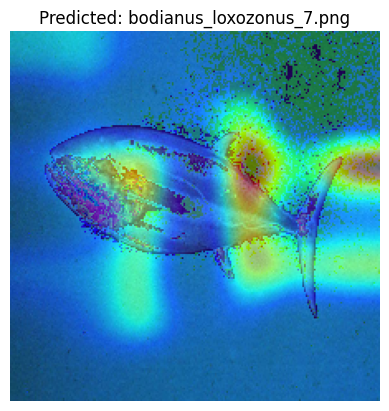

In [21]:

activation_map = cam_extractor(class_idx, out)


result = overlay_mask(to_pil_image(input_tensor.squeeze().cpu()), to_pil_image(activation_map[0].squeeze().cpu(), mode='F'), alpha=0.5)


plt.imshow(result)
plt.title(f"Predicted: {class_names[class_idx]}")
plt.axis('off')
plt.show()


In [22]:
result.save("gradcam_result.jpg")
print("Heatmap saved as gradcam_result.jpg")


Heatmap saved as gradcam_result.jpg


In [23]:
import torchvision.models as models
import torch

model = models.resnet18(pretrained=True)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

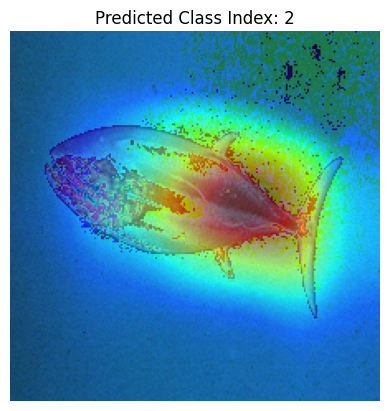

✅ Grad-CAM saved as gradcam_result.jpg


In [24]:
# Install Grad-CAM package
!pip install -q torchcam

# Imports
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
from PIL import Image
import os

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load model and set to eval
model = resnet18(pretrained=True)
model.eval()
model.to(device)

# Load an image
data_dir = '/content/marine_species/Fish_Data/images/cropped'
image_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]
img_path = os.path.join(data_dir, image_files[0])
img = Image.open(img_path).convert('RGB')

# Preprocess image
input_tensor = transform(img).unsqueeze(0).to(device)

# Grad-CAM setup
cam_extractor = GradCAM(model, target_layer='layer4')

# Forward pass
out = model(input_tensor)
class_idx = out.squeeze(0).argmax().item()

# Generate activation map
activation_map = cam_extractor(class_idx, out)

# Overlay heatmap
result = overlay_mask(
    to_pil_image(input_tensor.squeeze(0).cpu(), mode='RGB'),
    to_pil_image(activation_map[0].squeeze().cpu(), mode='F'),
    alpha=0.5
)

# Show and save result
plt.imshow(result)
plt.title(f"Predicted Class Index: {class_idx}")
plt.axis('off')
plt.show()

result.save("gradcam_result.jpg")
print("✅ Grad-CAM saved as gradcam_result.jpg")


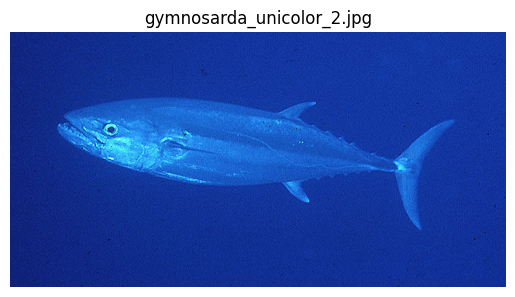

In [30]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Corrected image folder path
image_folder = '/content/marine_species/Fish_Data/images/cropped'
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.jpg')])
image_files = image_files[:5]  # fewer for testing

for img_file in image_files:
    img_path = os.path.join(image_folder, img_file)
    img = Image.open(img_path).convert('RGB')
    plt.imshow(img)
    plt.title(f"{img_file}")
    plt.axis('off')
    plt.show()

In [33]:
ground_truth = {}
for img_file in image_files:
    label = input(f"Enter label for {img_file}: ")
    ground_truth[img_file] = label

# Display collected labels
print("\nCollected Ground Truth Labels:")
for k, v in ground_truth.items():
    print(f"{k} --> {v}")


Enter label for gymnosarda_unicolor_2.jpg: true

Collected Ground Truth Labels:
gymnosarda_unicolor_2.jpg --> true


In [35]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.3 MB/s eta 0:00:00


In [44]:
import torch
import torchvision.models as models

# Load the model (assuming you're using resnet18)
model = models.resnet18(pretrained=True)

# Load the previously saved state_dict if available
try:
    model.load_state_dict(torch.load("model.pth"))
    print("Loaded model state from model.pth")
except FileNotFoundError:
    print("model.pth not found, starting with a fresh model")

# ... rest of your code for training or inference ...

# Save the model state
torch.save(model.state_dict(), "model.pth")
from google.colab import files
files.download("model.pth")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


model.pth not found, starting with a fresh model


<ipython-input-44-23ffe3a8f125>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pth"))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
torch.save(model.state_dict(), "model.pth")
from google.colab import files
files.download("model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
import streamlit as st
import torch
from torchvision import models, transforms
from PIL import Image

# Title
st.title("Marine Species Classifier")

import streamlit as st
import torch
from torchvision import models, transforms
from PIL import Image

# Title
st.title("Marine Species Classifier")

# Load your model
@st.cache_resource
def load_():
    pass

2025-04-17 21:28:40.427 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-17 21:28:40.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-17 21:28:40.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-17 21:28:40.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [41]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [56]:
import torch
from torchvision import models

# Step 1: Load your trained model (from previous export)
model = models.resnet18(pretrained=False)
# use your class count, here assumed to be 3
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 3)

# Load your full weights, but only load the matching keys
state_dict = torch.load("/content/resnet18_state_dict.pth", map_location='cpu')
# Filter out the 'fc' layer weights from the state dict
state_dict = {k: v for k, v in state_dict.items() if not k.startswith('fc.')}

# Now load the modified state dict
model.load_state_dict(state_dict, strict=False)

# Step 2: Convert all weights to float16 (reduces file size)
for param in model.parameters():
    param.data = param.data.half()

# Step 3: Save a smaller version
torch.save(model.state_dict(), "/content/resnet18_half_precision.pth")
print("✅ Saved smaller model as resnet18_half_precision.pth")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-56-6ffbcf858e59>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

✅ Saved smaller model as resnet18_half_precision.pth


In [5]:
import torch # Importing the torch library
import torchvision.models as models
import torch.nn as nn

# Assuming you're using resnet18
model = models.resnet18(pretrained=True)

# If you have a specific number of classes, adjust the final layer
num_classes = 5  # Replace with your actual number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Now you can save the model
torch.save(model, "model.pth")

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models

class MarineSpeciesModel(nn.Module):
    def __init__(self, base_model):
        super(MarineSpeciesModel, self).__init__()
        self.base_model = base_model
        # Get the number of features in the last layer of the base model
        num_ftrs = self.base_model.fc.in_features
        # Replace the last layer with a new layer

In [8]:
torch.save(model.state_dict(), 'model.pth')


In [9]:
torch.save(model.state_dict(), 'resnet18_half_precision.pth')


In [10]:
pip install opencv-python-headless

In [12]:
!sudo apt-get update
!sudo apt-get install -y libgl1-mesa-glx
!pip install opencv-python

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,384 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,692 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/m

In [57]:
from google.colab import files
files.download("/content/resnet18_half_precision.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>